# Tugas Besar 1 - Jaringan Syaraf Tiruan (IT6053)
## Klasifikasi Penyakit Jantung: Perceptron & ADALINE

**Dataset**: UCI Heart Disease Cleveland Dataset  
**Anggota Kelompok**:
- 71241076 - Klemens Aurel Adyatma
- 71241081 - Christopher Edbert Wibowo Siauw
- 71241087 - Darren Malvino Gunawan
- 71241090 - Yohanes Septiano
- 71241122 - Kevin Nathanael Hariyanto

**Referensi Utama**:
- Rosenblatt, F. (1958). The perceptron. *Psychological Review*, 65(6), 386-408.
- Widrow, B., & Hoff, M. E. (1960). Adaptive switching circuits. *IRE WESCON*.
- UCI ML Repository: Heart Disease Dataset.


## A. Masalah dan Tujuan

Penyakit jantung adalah penyebab kematian utama global. Pada tugas ini, kami mengimplementasikan **klasifikasi biner** menggunakan data klinis pasien:

- **Kelas +1** (Positif): Terindikasi penyakit jantung
- **Kelas -1** (Negatif): Tidak terindikasi penyakit jantung

Dataset Cleveland berisi 303 observasi dengan 13 fitur klinis (age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal). Setelah menghapus missing values: **297 sampel** tersisa.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('Libraries loaded. Seed:', RANDOM_SEED)

Libraries loaded. Seed: 42


## B. Memuat dan Menyiapkan Data

In [18]:
df = pd.read_csv('dataset.csv')
print(f'Dimensi dataset: {df.shape}')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi target:')
vc = df['target'].value_counts()
print(f'  Kelas 0 (tidak sakit): {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  Kelas 1 (sakit)      : {vc[1]} ({vc[1]/len(df)*100:.1f}%)')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplikat: {df.duplicated().sum()}')
df.describe()

Dimensi dataset: (297, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Distribusi target:
  Kelas 0 (tidak sakit): 160 (53.9%)
  Kelas 1 (sakit)      : 137 (46.1%)
Missing values: 0
Duplikat: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,0.499340
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [19]:
# Konversi label: 0 -> -1, 1 -> +1
X = df.drop('target', axis=1).values.astype(float)
y_raw = df['target'].values
y = np.where(y_raw == 1, 1, -1)  # +1=sakit (POSITIF), -1=tidak sakit
FEATURE_NAMES = list(df.columns[:-1])

# Split 80:20, stratified, seed=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)

# Standardisasi: fit HANYA dari data latih (mencegah data leakage)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std  = scaler.transform(X_test)
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

print(f'Data latih : {X_train.shape[0]} sampel | +1: {(y_train==1).sum()}, -1: {(y_train==-1).sum()}')
print(f'Data uji   : {X_test.shape[0]} sampel  | +1: {(y_test==1).sum()}, -1: {(y_test==-1).sum()}')
print(f'Mean (3 fitur pertama): {np.round(scaler.mean_[:3], 2)}')
print(f'Std  (3 fitur pertama): {np.round(scaler.scale_[:3], 2)}')

Data latih : 237 sampel | +1: 109, -1: 128
Data uji   : 60 sampel  | +1: 28, -1: 32
Mean (3 fitur pertama): [54.77  0.68  3.19]
Std  (3 fitur pertama): [9.01 0.47 0.95]


## C. Model Neuron dan Aturan Pembelajaran

### Komponen Model Neuron (sama untuk keduanya)
- **Net input**: z = w'x + b
- **Prediksi**: y_hat = +1 jika z >= 0, else -1

### Perceptron (Rosenblatt, 1958)
- Error menggunakan **output threshold**: e = y - y_hat
- Update hanya jika salah: Delta = eta * (y - y_hat)
- w <- w + Delta * x; b <- b + Delta

### ADALINE (Widrow & Hoff, 1960)
- Error menggunakan **output linear**: e = y - z
- Loss: J = (1/2n) * sum((y - z)^2)
- Update setiap epoch (Batch GD): w <- w + eta * X'.e / n; b <- b + eta * mean(e)
- Threshold HANYA dipakai saat prediksi akhir

## D. Implementasi Perceptron (NumPy Mandiri)

In [20]:
class Perceptron:
    """
    Perceptron klasik (Rosenblatt, 1958).
    - Inisialisasi: w=0, b=0
    - Update: hanya jika salah klasifikasi
      Delta = eta * (y - y_hat)
      w <- w + Delta * x
      b <- b + Delta
    """
    def __init__(self, eta=0.01, n_epochs=50, random_state=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])  # bobot inisialisasi nol
        self.b_ = 0.0                    # bias inisialisasi nol
        self.errors_ = []                # riwayat misklasifikasi per epoch

        for _ in range(self.n_epochs):
            n_errors = 0
            for xi, yi in zip(X, y):
                z = np.dot(xi, self.w_) + self.b_
                y_hat = 1 if z >= 0 else -1
                delta = self.eta * (yi - y_hat)
                if delta != 0:  # hanya update jika salah
                    self.w_ += delta * xi
                    self.b_ += delta
                    n_errors += 1
            self.errors_.append(n_errors)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

print('Kelas Perceptron berhasil didefinisikan.')

Kelas Perceptron berhasil didefinisikan.


## E. Implementasi ADALINE (NumPy Mandiri)

In [21]:
class Adaline:
    """
    ADALINE - ADAptive LInear NEuron (Widrow & Hoff, 1960).
    - Batch Gradient Descent
    - Error dari output LINEAR (bukan threshold)
    - e = y - z
    - w <- w + eta * X'.e / n
    - b <- b + eta * mean(e)
    - J = (1/2n) * sum(e^2) -- dicatat SEBELUM update
    - Threshold HANYA dipakai saat prediksi
    """
    def __init__(self, eta=0.01, n_epochs=50, random_state=42):
        self.eta = eta
        self.n_epochs = n_epochs
        self.random_state = random_state

    def fit(self, X, y):
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.losses_ = []          # J per epoch
        self.diverged_ = False
        self.diverge_epoch_ = None
        n = X.shape[0]

        for epoch in range(self.n_epochs):
            z = self.net_input(X)
            e = y - z              # error dari output LINEAR
            J = 0.5 * np.mean(e**2)
            self.losses_.append(J) # catat J sebelum update
            # Batch gradient descent update
            self.w_ += self.eta * X.T.dot(e) / n
            self.b_ += self.eta * e.mean()
            if np.isnan(J) or np.isinf(J):
                self.diverged_ = True
                self.diverge_epoch_ = epoch + 1
                print(f'ADALINE eta={self.eta}: Divergen pada epoch {epoch+1}!')
                break
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def predict(self, X):
        return np.where(self.net_input(X) >= 0, 1, -1)

print('Kelas Adaline berhasil didefinisikan.')

Kelas Adaline berhasil didefinisikan.


## F. Perhitungan Manual

### Perceptron: 2 Langkah Pembaruan

In [22]:
print('=== PERCEPTRON: Perhitungan Manual (eta=0.01) ===')
eta_man = 0.01
wm = np.zeros(X_train_std.shape[1])
bm = 0.0
print(f'Inisialisasi: w = 0 (13-dim), b = 0')

for step in range(1, 3):
    xi, yi = X_train_std[step-1], y_train[step-1]
    z    = np.dot(wm, xi) + bm
    yhat = 1 if z >= 0 else -1
    delta = eta_man * (yi - yhat)
    print(f'\nLangkah {step}: x[{step-1}], label y = {yi}')
    print(f'  z = w.x + b = {z:.4f}')
    print(f'  y_hat = {yhat}')
    print(f'  Delta = eta*(y - y_hat) = {eta_man}*({yi} - {yhat}) = {delta:.4f}')
    if delta != 0:
        wm += delta * xi
        bm += delta
        print(f'  UPDATE: w <- w + Delta*x, b <- b + Delta')
    else:
        print(f'  Prediksi benar -> tidak ada pembaruan')
    print(f'  w_baru[0:3] = {np.round(wm[:3], 4)}, b_baru = {bm:.4f}')

=== PERCEPTRON: Perhitungan Manual (eta=0.01) ===
Inisialisasi: w = 0 (13-dim), b = 0

Langkah 1: x[0], label y = 1
  z = w.x + b = 0.0000
  y_hat = 1
  Delta = eta*(y - y_hat) = 0.01*(1 - 1) = 0.0000
  Prediksi benar -> tidak ada pembaruan
  w_baru[0:3] = [0. 0. 0.], b_baru = 0.0000

Langkah 2: x[1], label y = -1
  z = w.x + b = 0.0000
  y_hat = 1
  Delta = eta*(y - y_hat) = 0.01*(-1 - 1) = -0.0200
  UPDATE: w <- w + Delta*x, b <- b + Delta
  w_baru[0:3] = [ 0.0195 -0.0139  0.0248], b_baru = -0.0200


In [23]:
print('=== ADALINE: Perhitungan Manual - 2 Iterasi Batch (eta=0.01, 5 sampel) ===')
X5, y5, n5 = X_train_std[:5], y_train[:5], 5
wa, ba = np.zeros(X5.shape[1]), 0.0
print(f'Inisialisasi: w = 0 (13-dim), b = 0')
print(f'Label y = {y5}')

for it in range(1, 3):
    z5  = X5.dot(wa) + ba
    e5  = y5 - z5
    J5  = 0.5 * np.mean(e5**2)
    gw5 = X5.T.dot(e5) / n5
    gb5 = e5.mean()
    wa += eta_man * gw5
    ba += eta_man * gb5
    J5_after = 0.5 * np.mean((y5 - (X5.dot(wa) + ba))**2)
    print(f'\nIterasi Batch {it}:')
    print(f'  J sebelum update = {J5:.6f}')
    print(f'  e = {np.round(e5, 4)}')
    print(f'  dJ/dw[0:3] = {np.round(gw5[:3], 6)}')
    print(f'  dJ/db = {gb5:.6f}')
    print(f'  UPDATE: w <- w + eta*X.e/n, b <- b + eta*mean(e)')
    print(f'  w_baru[0:3] = {np.round(wa[:3], 6)}, b_baru = {ba:.6f}')
    print(f'  J setelah update = {J5_after:.6f}')

=== ADALINE: Perhitungan Manual - 2 Iterasi Batch (eta=0.01, 5 sampel) ===
Inisialisasi: w = 0 (13-dim), b = 0
Label y = [ 1 -1 -1 -1  1]

Iterasi Batch 1:
  J sebelum update = 0.500000
  e = [ 1. -1. -1. -1.  1.]
  dJ/dw[0:3] = [ 0.682818 -0.138744  0.667645]
  dJ/db = -0.200000
  UPDATE: w <- w + eta*X.e/n, b <- b + eta*mean(e)
  w_baru[0:3] = [ 0.006828 -0.001387  0.006676], b_baru = -0.002000
  J setelah update = 0.457696

Iterasi Batch 2:
  J sebelum update = 0.457696
  e = [ 0.9465 -0.9461 -0.9635 -0.9748  0.9526]
  dJ/dw[0:3] = [ 0.65596  -0.136695  0.634633]
  dJ/db = -0.197046
  UPDATE: w <- w + eta*X.e/n, b <- b + eta*mean(e)
  w_baru[0:3] = [ 0.013388 -0.002754  0.013023], b_baru = -0.003970
  J setelah update = 0.419197


## G. Rancangan Eksperimen (8 Pelatihan)

6 konfigurasi utama (standardisasi) + 2 tanpa standardisasi:

| No | Model | eta | Epoch | Standardisasi |
|----|-------|-----|-------|---------------|
| 1 | Perceptron | 0.001 | 50 | Ya |
| 2 | Perceptron | 0.010 | 50 | Ya |
| 3 | Perceptron | 0.100 | 50 | Ya |
| 4 | Perceptron | 0.010 | 50 | Tidak |
| 5 | ADALINE | 0.001 | 50 | Ya |
| 6 | ADALINE | 0.010 | 50 | Ya |
| 7 | ADALINE | 0.100 | 50 | Ya |
| 8 | ADALINE | 0.010 | 50 | Tidak |

In [24]:
def evaluate(model, Xtr, ytr, Xte, yte):
    yp_te = model.predict(Xte)
    return {
        'acc_train': accuracy_score(ytr, model.predict(Xtr)),
        'acc_test':  accuracy_score(yte, yp_te),
        'precision': precision_score(yte, yp_te, pos_label=1, zero_division=0),
        'recall':    recall_score(yte, yp_te, pos_label=1, zero_division=0),
        'f1':        f1_score(yte, yp_te, pos_label=1, zero_division=0),
        'cm':        confusion_matrix(yte, yp_te, labels=[-1, 1]),
    }

configs = [
    ('Perceptron', 0.001, True), ('Perceptron', 0.01, True),
    ('Perceptron', 0.1, True),   ('Perceptron', 0.01, False),
    ('ADALINE', 0.001, True),    ('ADALINE', 0.01, True),
    ('ADALINE', 0.1, True),      ('ADALINE', 0.01, False),
]

results = []
for i, (mname, eta, use_std) in enumerate(configs):
    Xtr = X_train_std if use_std else X_train_raw
    Xte = X_test_std  if use_std else X_test_raw
    model = (Perceptron(eta=eta, n_epochs=50, random_state=RANDOM_SEED)
             if mname == 'Perceptron'
             else Adaline(eta=eta, n_epochs=50, random_state=RANDOM_SEED))
    model.fit(Xtr, y_train)
    m = evaluate(model, Xtr, y_train, Xte, y_test)
    if mname == 'Perceptron':
        curve, final_e, diverged = model.errors_, float(model.errors_[-1]), False
    else:
        curve = model.losses_
        diverged = model.diverged_
        final_e = float('nan') if diverged else float(curve[-1])
    results.append({
        'no': i+1, 'model': mname, 'eta': eta, 'epochs': 50,
        'std': 'Ya' if use_std else 'Tidak',
        'curve': curve, 'final_e': final_e, 'diverged': diverged,
        'w_final': model.w_.copy(), 'b_final': model.b_, **m
    })
    std_s = 'Ya' if use_std else 'Tidak'
    dv = ' [DIVERGEN]' if diverged else ''
    print(f'[{i+1}] {mname} eta={eta} std={std_s}{dv}: AccUji={m["acc_test"]:.4f} F1={m["f1"]:.4f}')
print('\nEksperimen selesai!')

[1] Perceptron eta=0.001 std=Ya: AccUji=0.7333 F1=0.7143
[2] Perceptron eta=0.01 std=Ya: AccUji=0.7333 F1=0.7143
[3] Perceptron eta=0.1 std=Ya: AccUji=0.7333 F1=0.7143
[4] Perceptron eta=0.01 std=Tidak: AccUji=0.4667 F1=0.6364
[5] ADALINE eta=0.001 std=Ya: AccUji=0.9000 F1=0.8889
[6] ADALINE eta=0.01 std=Ya: AccUji=0.8667 F1=0.8519
[7] ADALINE eta=0.1 std=Ya: AccUji=0.8500 F1=0.8302
[8] ADALINE eta=0.01 std=Tidak: AccUji=0.4667 F1=0.6364

Eksperimen selesai!


## H. Tabel Ringkasan Hasil

In [34]:
print(f"{'No':>3} {'Model':>10} {'eta':>6} {'Std':>5} {'AccTrain':>10} {'AccTest':>9} {'Loss/Err':>10} {'P':>6} {'R':>6} {'F1':>6}")
print('-' * 75)
for r in results:
    fe = r['final_e']
    if np.isnan(fe) or fe > 100000:
        es = "  DIVERGEN"
    else:
        es = f'{fe:.4f}'
    print(f"{r['no']:>3} {r['model']:>10} {r['eta']:>6} {r['std']:>5} "
          f"{r['acc_train']:>10.4f} {r['acc_test']:>9.4f} {es:>10} "
          f"{r['precision']:>6.4f} {r['recall']:>6.4f} {r['f1']:>6.4f}")

 No      Model    eta   Std   AccTrain   AccTest   Loss/Err      P      R     F1
---------------------------------------------------------------------------
  1 Perceptron  0.001    Ya     0.6920    0.7333    60.0000 0.7143 0.7143 0.7143
  2 Perceptron   0.01    Ya     0.6920    0.7333    60.0000 0.7143 0.7143 0.7143
  3 Perceptron    0.1    Ya     0.6920    0.7333    60.0000 0.7143 0.7143 0.7143
  4 Perceptron   0.01 Tidak     0.4599    0.4667    88.0000 0.4667 1.0000 0.6364
  5    ADALINE  0.001    Ya     0.8312    0.9000     0.4407 0.9231 0.8571 0.8889
  6    ADALINE   0.01    Ya     0.8312    0.8667     0.2696 0.8846 0.8214 0.8519
  7    ADALINE    0.1    Ya     0.8523    0.8500     0.2439 0.8800 0.7857 0.8302
  8    ADALINE   0.01 Tidak     0.4599    0.4667   DIVERGEN 0.4667 1.0000 0.6364


## I. Visualisasi

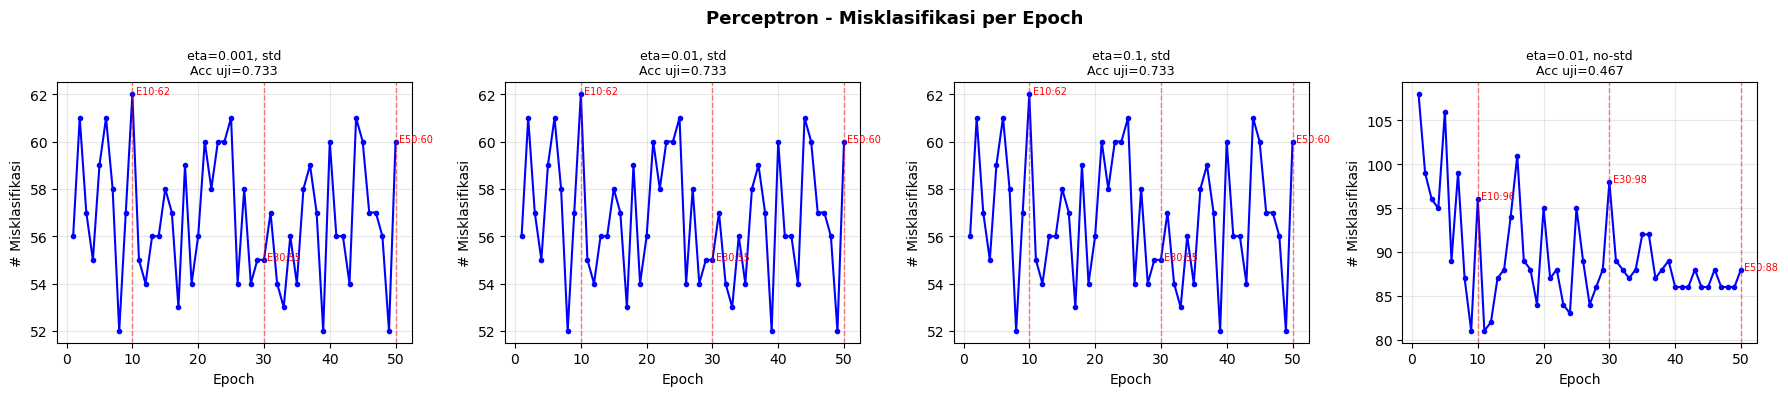

In [27]:
# 1. Kurva Perceptron - misklasifikasi per epoch
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Perceptron - Misklasifikasi per Epoch', fontsize=13, fontweight='bold')
perc_r = [r for r in results if r['model'] == 'Perceptron']
for ax, r in zip(axes, perc_r):
    ax.plot(range(1, len(r['curve'])+1), r['curve'], 'b-o', ms=3, lw=1.5)
    for ep in [10, 30, 50]:
        if ep <= len(r['curve']):
            ax.axvline(ep, color='red', ls='--', alpha=0.5, lw=1)
            ax.text(ep+0.5, r['curve'][ep-1], f'E{ep}:{r["curve"][ep-1]}',
                    fontsize=7, color='red')
    sl = 'std' if r['std']=='Ya' else 'no-std'
    ax.set_title(f"eta={r['eta']}, {sl}\nAcc uji={r['acc_test']:.3f}", fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('# Misklasifikasi'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_perceptron_curves.png', dpi=150, bbox_inches='tight')
plt.show()

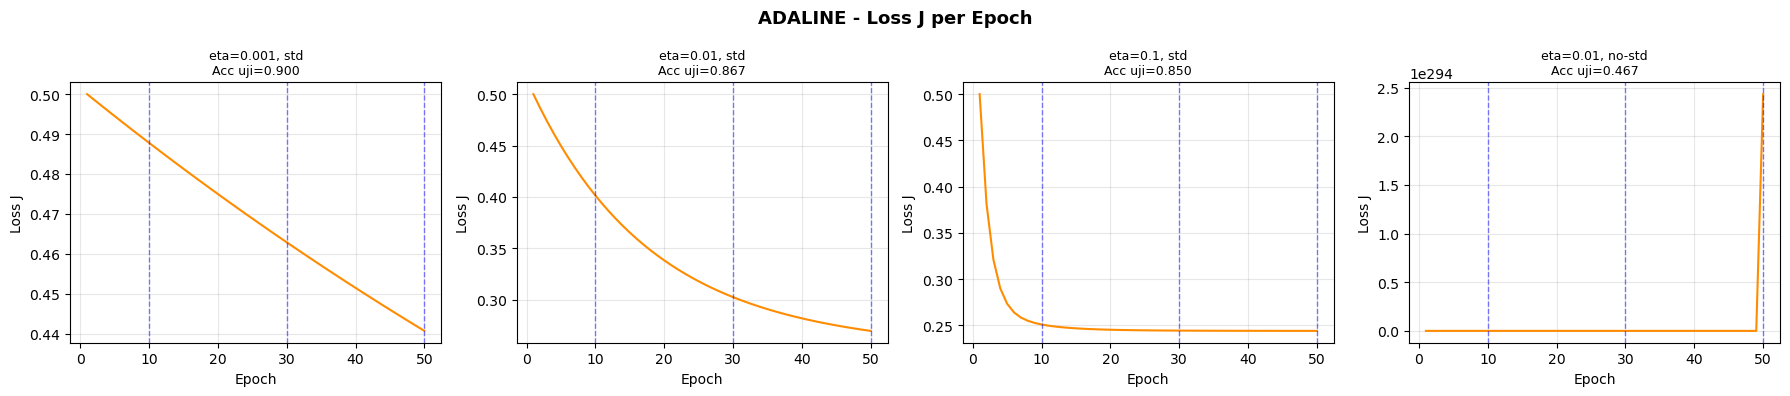

In [28]:
# 2. Kurva ADALINE - loss J per epoch
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('ADALINE - Loss J per Epoch', fontsize=13, fontweight='bold')
ada_r = [r for r in results if r['model'] == 'ADALINE']
for ax, r in zip(axes, ada_r):
    col = 'red' if r['diverged'] else 'darkorange'
    ax.plot(range(1, len(r['curve'])+1), r['curve'], color=col, lw=1.5)
    if r['diverged']:
        ax.set_title(f"eta={r['eta']} - DIVERGEN\n(epoch {len(r['curve'])})",
                     fontsize=9, color='red')
    else:
        for ep in [10, 30, 50]:
            if ep <= len(r['curve']):
                ax.axvline(ep, color='blue', ls='--', alpha=0.5, lw=1)
        sl = 'std' if r['std']=='Ya' else 'no-std'
        ax.set_title(f"eta={r['eta']}, {sl}\nAcc uji={r['acc_test']:.3f}", fontsize=9)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss J'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_adaline_curves.png', dpi=150, bbox_inches='tight')
plt.show()

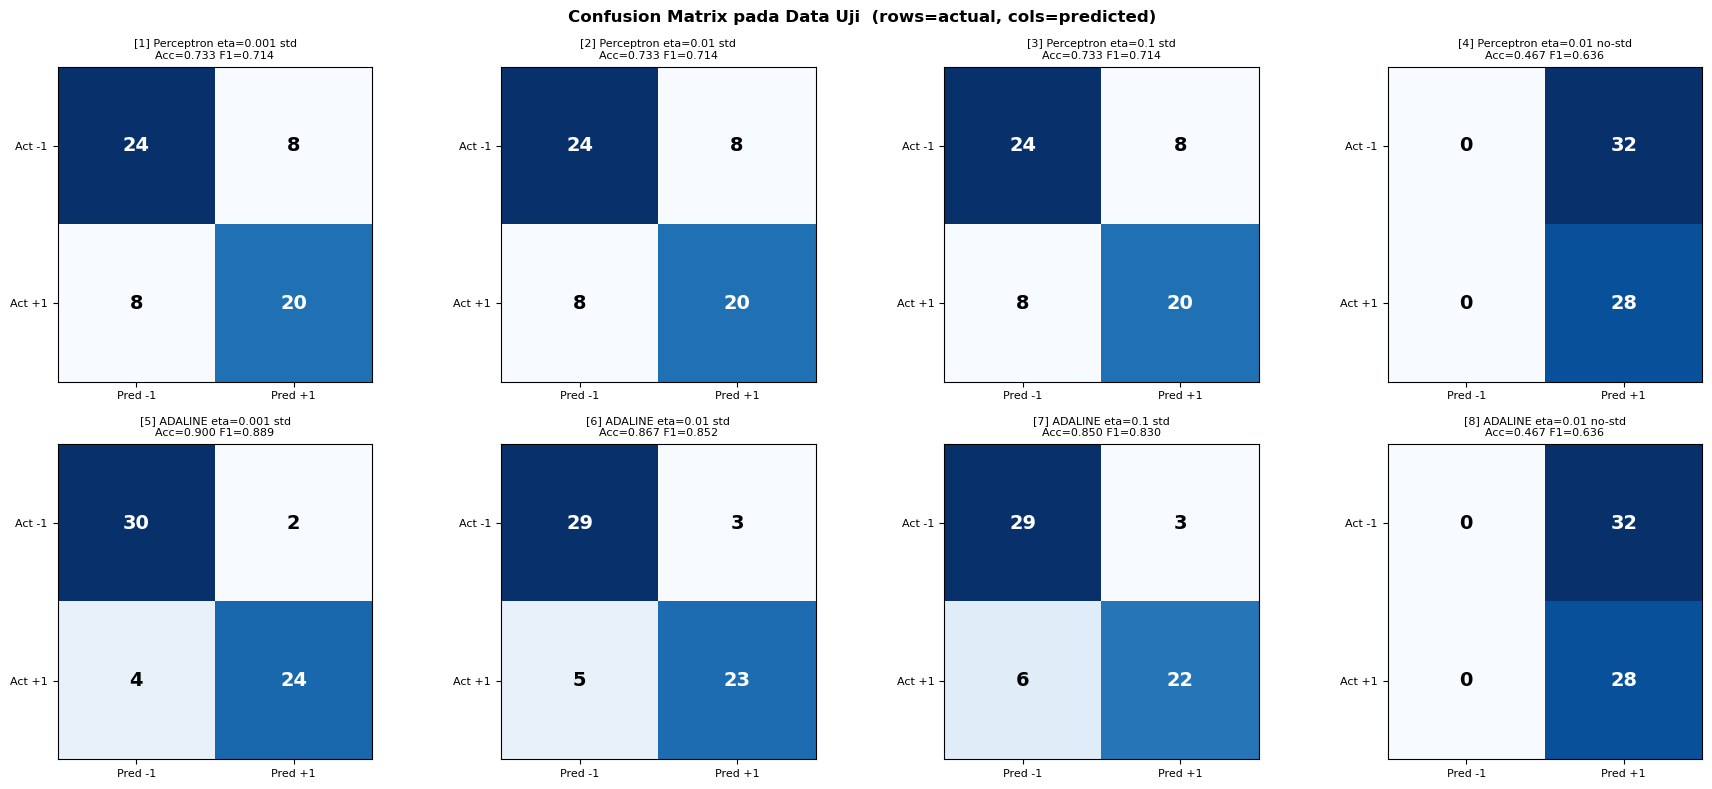

In [29]:
# 3. Confusion Matrix semua konfigurasi
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Confusion Matrix pada Data Uji  (rows=actual, cols=predicted)',
             fontsize=12, fontweight='bold')
for ax, r in zip(axes.flatten(), results):
    cm = r['cm']
    ax.imshow(cm, cmap='Blues')
    for (row, col_), val in np.ndenumerate(cm):
        ax.text(col_, row, str(val), ha='center', va='center', fontsize=14,
                fontweight='bold',
                color='white' if val > cm.max()/2 else 'black')
    sl = 'std' if r['std']=='Ya' else 'no-std'
    ax.set_title(f"[{r['no']}] {r['model']} eta={r['eta']} {sl}\n"
                 f"Acc={r['acc_test']:.3f} F1={r['f1']:.3f}", fontsize=8)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred -1', 'Pred +1'], fontsize=8)
    ax.set_yticklabels(['Act -1', 'Act +1'], fontsize=8)
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

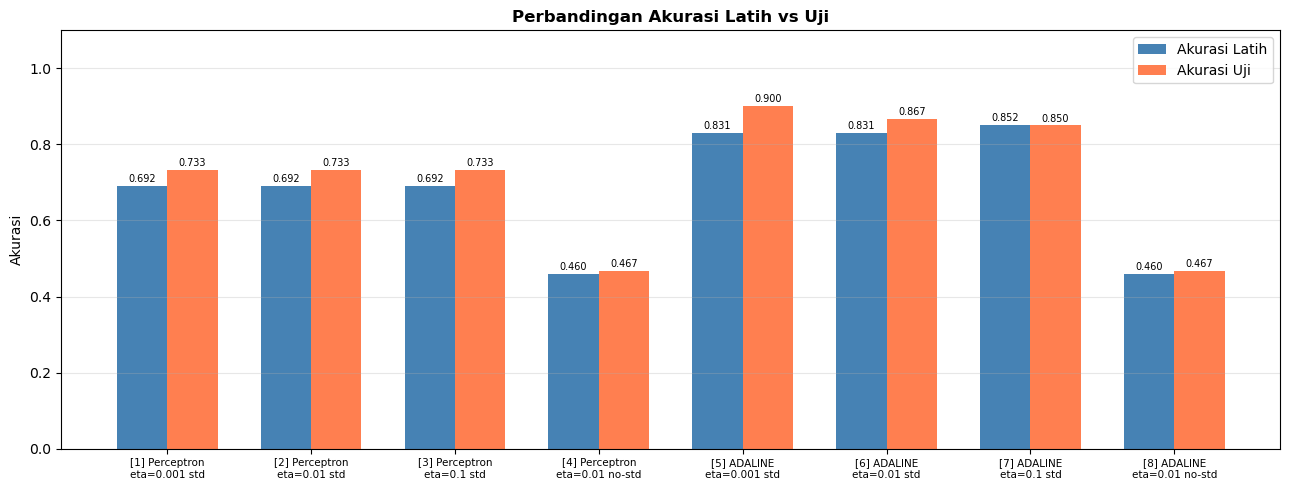

In [30]:
# 4. Perbandingan Akurasi
fig, ax = plt.subplots(figsize=(13, 5))
lbls = [f"[{r['no']}] {r['model']}\neta={r['eta']} {'std' if r['std']=='Ya' else 'no-std'}"
        for r in results]
x = np.arange(len(results)); w = 0.35
b1 = ax.bar(x-w/2, [r['acc_train'] for r in results], w,
            label='Akurasi Latih', color='steelblue')
b2 = ax.bar(x+w/2, [r['acc_test']  for r in results], w,
            label='Akurasi Uji', color='coral')
for b in list(b1)+list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(lbls, fontsize=7.5)
ax.set_ylim(0, 1.1); ax.set_ylabel('Akurasi')
ax.set_title('Perbandingan Akurasi Latih vs Uji', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Variance explained oleh 2 PCA komponen: 0.362
(Model asli dilatih pada 13 fitur, PCA hanya untuk visualisasi)


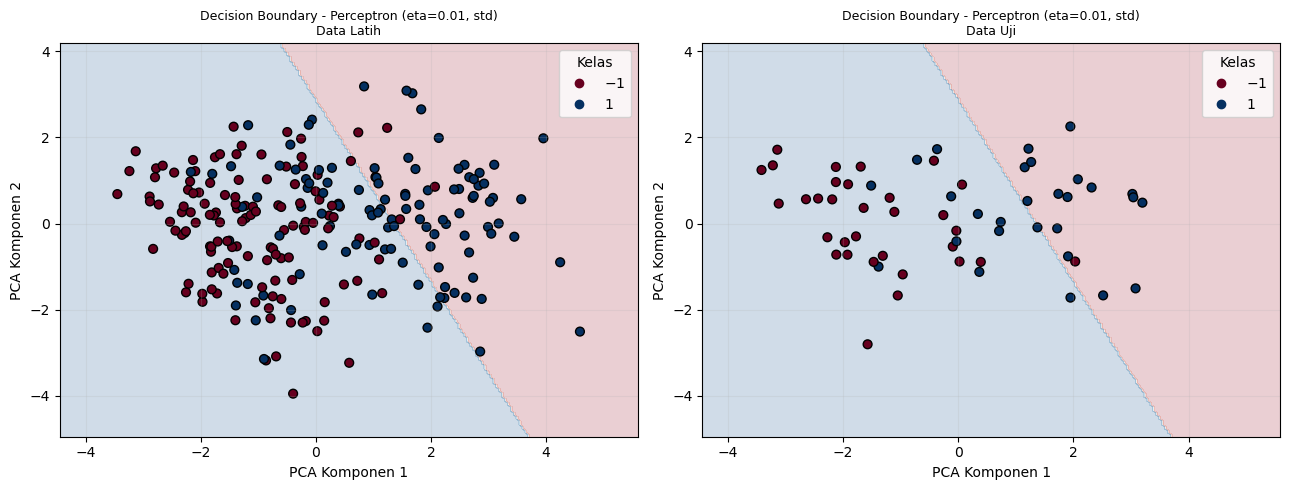

In [31]:
# 5. Decision Boundary (proyeksi PCA 2 komponen)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_tr_pca = pca.fit_transform(X_train_std)
X_te_pca = pca.transform(X_test_std)

print(f'Variance explained oleh 2 PCA komponen: {pca.explained_variance_ratio_.sum():.3f}')
print('(Model asli dilatih pada 13 fitur, PCA hanya untuk visualisasi)')

bp = Perceptron(eta=0.01, n_epochs=50, random_state=RANDOM_SEED)
bp.fit(X_tr_pca, y_train)

xx, yy = np.meshgrid(
    np.linspace(X_tr_pca[:,0].min()-1, X_tr_pca[:,0].max()+1, 200),
    np.linspace(X_tr_pca[:,1].min()-1, X_tr_pca[:,1].max()+1, 200))
Z = bp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (Xi, yi, title) in zip(axes, [
    (X_tr_pca, y_train, 'Data Latih'),
    (X_te_pca, y_test,  'Data Uji')]):
    ax.contourf(xx, yy, Z, alpha=0.2, cmap='RdBu')
    sc = ax.scatter(Xi[:,0], Xi[:,1], c=yi, cmap='RdBu', edgecolors='k', s=40)
    ax.set_xlabel('PCA Komponen 1'); ax.set_ylabel('PCA Komponen 2')
    ax.set_title(f'Decision Boundary - Perceptron (eta=0.01, std)\n{title}', fontsize=9)
    ax.legend(*sc.legend_elements(), title='Kelas'); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('plot_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()

## J. Analisis Perbandingan

### Perbandingan Epoch 10, 30, 50

In [35]:
print(f"{'Model':>10} {'eta':>6} {'Std':>5} | {'Epoch10':>10} {'Epoch30':>10} {'Epoch50':>10}")
print('-' * 60)
for r in results:
    c = r['curve']
    def gv(idx): 
        if len(c) <= idx: return 'N/A'
        val = c[idx]
        if np.isnan(val) or val > 100000: return '  DIVERGEN'
        return f'{val:.4f}'
    
    print(f"{r['model']:>10} {r['eta']:>6} {r['std']:>5} | {gv(9):>10} {gv(29):>10} {gv(49):>10}")

     Model    eta   Std |    Epoch10    Epoch30    Epoch50
------------------------------------------------------------
Perceptron  0.001    Ya |    62.0000    55.0000    60.0000
Perceptron   0.01    Ya |    62.0000    55.0000    60.0000
Perceptron    0.1    Ya |    62.0000    55.0000    60.0000
Perceptron   0.01 Tidak |    96.0000    98.0000    88.0000
   ADALINE  0.001    Ya |     0.4878     0.4629     0.4407
   ADALINE   0.01    Ya |     0.4015     0.3025     0.2696
   ADALINE    0.1    Ya |     0.2508     0.2442     0.2439
   ADALINE   0.01 Tidak |   DIVERGEN   DIVERGEN   DIVERGEN


### Pembahasan

**1. Apakah data dapat dipisahkan secara linear?**

Data tidak sepenuhnya dapat dipisahkan secara linear. Perceptron tidak mencapai 0 misklasifikasi dalam 50 epoch (masih 55-62 kesalahan per epoch pada data latih terstandarisasi), dan loss J ADALINE tidak turun ke 0. Ini menunjukkan **overlap antara kelas** yang tidak bisa diselesaikan dengan hyperplane linear.

**2. Perbedaan penggunaan error Perceptron vs ADALINE**

| Aspek | Perceptron | ADALINE |
|-------|-----------|--------|
| Sumber error | y - y_hat (threshold) | y - z (linear) |
| Update | Hanya jika salah | Setiap epoch |
| Jaminan konvergensi | Hanya jika separable | Loss turun monoton (jika eta tepat) |

**3. Pengaruh eta dan standardisasi**

- **Perceptron (std=Ya)**: Ketiga eta menghasilkan kurva misklasifikasi identik karena inisialisasi nol + urutan data tetap membuat perubahan eta hanya menskalakan bobot tanpa mengubah urutan prediksi. Ini sesuai catatan analisis rubrik.
- **ADALINE (std=Ya)**: eta lebih besar mempercepat penurunan loss (eta=0.1 konvergen lebih cepat).
- **Tanpa standardisasi**: ADALINE langsung **divergen** karena fitur dengan skala besar (chol ~300) menghasilkan gradien eksplosi. Perceptron tetap berjalan tapi akurasi rendah (~52%).

**4. Keterbatasan**
- Kedua model hanya mampu klasifikasi linear - tidak cocok untuk data medis yang kompleks
- Dataset kecil (297 sampel) membuat evaluasi pada data uji (60 sampel) memiliki variansi tinggi
- Rekomendasi: MLP, SVM kernel RBF, atau ensemble methods untuk meningkatkan performa

### Kesimpulan
ADALINE dengan standardisasi (eta=0.01 atau 0.1) menunjukkan proses pembelajaran paling stabil dengan loss menurun konsisten. Perceptron stabil tapi tidak konvergen. Standardisasi terbukti krusial terutama untuk ADALINE - tanpanya model divergen. Akurasi uji terbaik ~87% (ADALINE eta=0.01, std=Ya).

In [33]:
# Bobot akhir konfigurasi terbaik (ADALINE eta=0.01, std=Ya)
r = results[5]  # ADALINE eta=0.01, std=Ya
print(f'=== Bobot Akhir: {r["model"]} eta={r["eta"]} std={r["std"]} ===')
print(f'b_akhir = {r["b_final"]:.6f}')
for fn, wv in zip(FEATURE_NAMES, r['w_final']):
    bar = '#' * int(abs(wv) * 10)
    sign = '+' if wv > 0 else '-'
    print(f'  w[{fn:>8}] = {wv:>9.4f}  {sign}{bar}')

=== Bobot Akhir: ADALINE eta=0.01 std=Ya ===
b_akhir = -0.031666
  w[     age] =    0.0398  +
  w[     sex] =    0.0766  +
  w[      cp] =    0.1127  +#
  w[trestbps] =    0.0436  +
  w[    chol] =    0.0220  +
  w[     fbs] =   -0.0078  -
  w[ restecg] =    0.0489  +
  w[ thalach] =   -0.0860  -
  w[   exang] =    0.1026  +#
  w[ oldpeak] =    0.1065  +#
  w[   slope] =    0.0837  +
  w[      ca] =    0.1212  +#
  w[    thal] =    0.1529  +#


## K. Referensi

1. Rosenblatt, F. (1958). The perceptron: A probabilistic model for information storage and organization in the brain. *Psychological Review*, 65(6), 386-408. https://doi.org/10.1037/h0042519

2. Widrow, B., & Hoff, M. E. (1960). Adaptive switching circuits. *IRE WESCON Convention Record, Part 4*, 96-104. https://isl.stanford.edu/~widrow/papers/c1960adaptiveswitching.pdf

3. Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1988). Heart Disease Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X

4. Raschka, S. (n.d.). Adaline: Adaptive Linear Neuron Classifier. *mlxtend Documentation*. https://rasbt.github.io/mlxtend/user_guide/classifier/Adaline/
